---
**`NOTEBOOK 02 / 03`** · Causal Inference Series

## Difference-in-Differences — Card & Krueger (1994)
*410 fast-food restaurants · NJ vs PA · Nobel Prize-winning study*

| | |
|--|--|
| Method | Difference-in-Differences (DiD) |
| Outcome | fte_obs (continuous) → OLS |
| Assumption | Parallel trends — defended with domain knowledge |
| Result | β₃ = +2.75 FTE · p = 0.103 · no job destruction |
| Causal hierarchy | ⭐⭐ Level 2 — natural experiment |

---

In April 1992, New Jersey raised its minimum wage from $4.25 to $5.05. Pennsylvania did not. Card & Krueger surveyed 410 fast-food restaurants in both states before (Feb 1992) and after (Nov 1992) the change. This is the study that won David Card the Nobel Prize in Economics in 2021.

DiD is the right method when randomization is impossible but a natural event creates near-random variation. We compare how employment *changed* in NJ vs PA — cancelling fixed differences between states and common time trends. What remains is the causal effect of the minimum wage.

**The causal question:** did raising the minimum wage reduce employment in fast-food restaurants?

---

## When to use DiD

DiD is the right method when:
- An **exogenous event** (policy change, tool rollout) hits one group and not another
- You have **before and after data** for both groups
- You cannot randomize — the treatment was assigned by circumstance, not by design

In our case: NJ raised the minimum wage (treated), PA did not (control).
We have employment data for both states before (Feb 1992) and after (Nov 1992).

---

## Critical Assumption — Parallel Trends

Without the minimum wage increase, NJ and PA employment would have evolved
identically. We verify this graphically before estimating anything.
If the trends diverge before treatment, DiD is invalid.

---

**Structure**

`0` Setup

`1` Identify the event

`2` Treated vs control groups

`2.5` Hypotheses

`3` Parallel trends

`4` DiD regression — OLS with interaction term nj:post

`5` Standard errors

`6` Results & business conclusion

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

ck_long = pd.read_csv("../data/card_krueger_long.csv")
print(f"Long format: {ck_long.shape[0]} rows x {ck_long.shape[1]} columns")
display(ck_long.sort_values(by="sheet").head(8))

Long format: 820 rows x 15 columns


,sheet,nj,bk,kfc,roys,wendys,co_owned,southj,centralj,northj,pa1,pa2,wage,fte_obs,post
579,1,1,1,0,0,0,0,0,1,0,0,0,5.05,44.0,1
169,1,1,1,0,0,0,0,0,1,0,0,0,4.50,35.0,0
170,2,1,1,0,0,0,0,0,1,0,0,0,4.75,16.0,0
580,2,1,1,0,0,0,0,0,1,0,0,0,5.25,15.5,1
581,3,1,0,1,0,0,0,0,1,0,0,0,5.05,10.5,1
171,3,1,0,1,0,0,0,0,1,0,0,0,4.25,15.5,0
172,4,1,0,0,1,0,0,0,1,0,0,0,4.75,19.0,0
582,4,1,0,0,1,0,0,0,1,0,0,0,5.05,24.0,1


## 1. Identify the Event and the date that splits "pre" from "post"

- **Event:** New Jersey raised its minimum wage from $4.25 to $5.05
- **Date:** April 1992
- **Pre-period:** February 1992 (post = 0)
- **Post-period:** November 1992 (post = 1)

In [2]:
print("Event summary:")
print(f"  Pre-period  (post=0): {ck_long[ck_long['post']==0].shape[0]} restaurant observations")
print(f"  Post-period (post=1): {ck_long[ck_long['post']==1].shape[0]} restaurant observations")
print(f"\nWage by state and period:")
ck_long.groupby(['nj', 'post'])['wage'].mean().unstack()\
    .rename(index={0:'Pennsylvania', 1:'New Jersey'},
            columns={0:'Pre (Feb 1992)', 1:'Post (Nov 1992)'})\
    .round(2)

Event summary:
  Pre-period  (post=0): 410 restaurant observations
  Post-period (post=1): 410 restaurant observations

Wage by state and period:


post,Pre (Feb 1992),Post (Nov 1992)
nj,,
Pennsylvania,4.63,4.62
New Jersey,4.61,5.08


## 2. Define Treated vs Control Groups

- **Treated:** New Jersey (`nj = 1`) — received the minimum wage increase
- **Control:** Pennsylvania (`nj = 0`) — no change in minimum wage

The two groups are comparable (parallel trends): neighboring states, same fast-food chains 
(Burger King, KFC, Roy Rogers, Wendys), similar labor markets.

In [3]:
print("Restaurants by state:")
print(f"  New Jersey (treated) : {ck_long[ck_long['nj']==1]['sheet'].nunique()} restaurants")
print(f"  Pennsylvania (control): {ck_long[ck_long['nj']==0]['sheet'].nunique()} restaurants")

print("\nRestaurants by chain:")
chains = ['bk', 'kfc', 'roys', 'wendys']
ck_long[ck_long['post']==0].groupby('nj')[chains].sum()\
    .rename(index={0:'Pennsylvania', 1:'New Jersey'})

Restaurants by state:
  New Jersey (treated) : 331 restaurants
  Pennsylvania (control): 79 restaurants

Restaurants by chain:


,bk,kfc,roys,wendys
nj,,,,
Pennsylvania,35,12,17,15
New Jersey,136,68,82,45


### Hypotheses

We fix the hypotheses before looking at any results.

**H₀:** the minimum wage increase had no effect on employment

**H₁:** the minimum wage increase or decreased employment

We do not impose a direction before seeing the data. Classical economics 
predicts job destruction (negative effect). Card & Krueger challenge that prediction.

The causal effect will be estimated by the interaction term `nj × post` 
in the DiD regression (block 4). That coefficient — β₃ — is the parameter 
we are testing: if β₃ = 0, the minimum wage had no effect; if β₃ ≠ 0, it did.

> Fixing hypotheses before seeing results avoids HARKing 
> (Hypothesizing After Results are Known) — the same rule as in an A/B test.

## 3. Check Parallel Trends

The critical assumption of DiD: without the minimum wage increase, 
NJ and PA employment would have evolved identically.

**The problem with this dataset:**
Card & Krueger only surveyed restaurants at two points in time 
(Feb 1992 and Nov 1992). With only two time points we cannot plot 
pre-treatment trends to verify this assumption graphically.

**How we defend it instead:**
- NJ and PA are neighboring states with similar economies
- Both have the same fast-food chains
- No other major policy change affected only NJ in this period

We verify what we can: that NJ and PA had similar employment levels 
in the pre-period, and that the pre-period trends look plausible.

Mean FTE by state and period:
                        Pre (Feb 1992)  Post (Nov 1992)  Change
Pennsylvania (control)           23.33            21.17   -2.17
New Jersey (treated)             20.44            21.03    0.59

Raw DiD estimate (ATT): 2.75 FTE employees


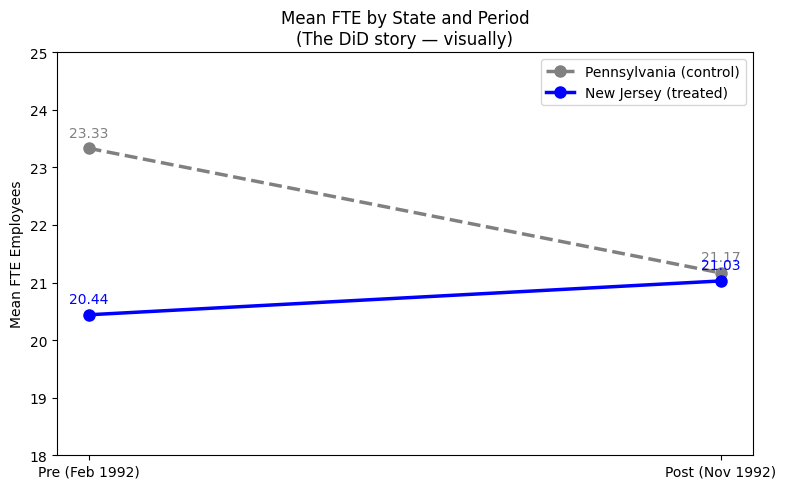

In [4]:
# Mean FTE by state and period
summary = ck_long.groupby(['nj', 'post'])['fte_obs'].mean().unstack()
summary.index   = ['Pennsylvania (control)', 'New Jersey (treated)']
summary.columns = ['Pre (Feb 1992)', 'Post (Nov 1992)']
summary['Change'] = summary['Post (Nov 1992)'] - summary['Pre (Feb 1992)']
print("Mean FTE by state and period:")
print(summary.round(2))

# Raw DiD estimate
att_raw = summary.loc['New Jersey (treated)', 'Change'] - summary.loc['Pennsylvania (control)', 'Change']
print(f"\nRaw DiD estimate (ATT): {att_raw:.2f} FTE employees")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

for state, color, ls in [('Pennsylvania (control)', 'gray', '--'),
                          ('New Jersey (treated)',   'blue', '-')]:
    vals = [summary.loc[state, 'Pre (Feb 1992)'],
            summary.loc[state, 'Post (Nov 1992)']]
    ax.plot(['Pre (Feb 1992)', 'Post (Nov 1992)'], vals,
            marker='o', markersize=8, color=color,
            linewidth=2.5, linestyle=ls, label=state)
    for x, y in zip(['Pre (Feb 1992)', 'Post (Nov 1992)'], vals):
        ax.text(x, y + 0.2, f'{y:.2f}', ha='center', fontsize=10, color=color)

ax.set_title('Mean FTE by State and Period\n(The DiD story — visually)')
ax.set_ylabel('Mean FTE Employees')
ax.set_ylim(18, 25)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Fit the DiD Regression

We now estimate the same effect formally with regression.
The interaction term `nj:post` gives us β₃ — the causal effect.

$$Y_{it} = \beta_0 + \beta_1 \cdot nj_i + \beta_2 \cdot post_t + \beta_3 \cdot (nj_i \times post_t) + \varepsilon_{it}$$

**Why OLS?**

Following the metric type decision framework:

| Metric type | Model |
|-------------|-------|
| Continuous symmetric | OLS ✓ our case |
| Binary (0/1) | Logistic with fixed effects |
| Count (events) | Poisson with fixed effects |
| Continuous skewed | OLS on log(Y) |

`fte_obs` is continuous — it can be 20.5, 21.3, 15.0. It is not binary 
or a pure integer count. It combines full-time + 0.5 × part-time + managers, 
producing a roughly symmetric continuous distribution.

The DiD formula does not change across metric types — only the model beneath it does.
In our case OLS is the correct choice.

In [5]:
modelo = smf.ols('fte_obs ~ nj + post + nj:post', data=ck_long).fit()

print(modelo.summary().tables[1])

beta3 = modelo.params['nj:post']
ci    = modelo.conf_int().loc['nj:post']
pval  = modelo.pvalues['nj:post']

print(f"\nCausal effect (β₃) : {beta3:.2f} FTE employees")
print(f"95% CI             : [{ci[0]:.2f}, {ci[1]:.2f}]")
print(f"p-value            : {pval:.4f}")
print(f"\nConclusion: {'✓ Significant' if pval < 0.05 else '✗ Not significant'}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.3312      1.072     21.767      0.000      21.227      25.435
nj            -2.8918      1.194     -2.423      0.016      -5.235      -0.549
post          -2.1656      1.516     -1.429      0.154      -5.141       0.810
nj:post        2.7536      1.688      1.631      0.103      -0.561       6.068

Causal effect (β₃) : 2.75 FTE employees
95% CI             : [-0.56, 6.07]
p-value            : 0.1033

Conclusion: ✗ Not significant


## 5. Standard Errors

Restaurants within the same state share the same economic context, 
laws, and labor market. Their outcomes are correlated — they are not 
independent observations.

If we ignore this, standard errors come out too small, p-values 
are artificially low, and we overstate significance.

The fix depends on how many clusters we have:

| Clusters | Treated clusters | Recommended approach |
|----------|-----------------|----------------------|
| 1-5 | 1 | OLS standard errors. No correction works reliably. Be transparent. |
| 6-20 | 2-10 | Wild cluster bootstrap (MacKinnon & Webb 2018) |
| 20-50 | 10+ | Wild cluster bootstrap or cluster-robust SE (CRVE) |
| 50+ | 25+ | Cluster-robust SE (CRVE) — fully reliable |

**Our case:** 2 states, 1 treated (NJ).

- Cluster-robust SE → requires 30-50+ clusters → not valid here
- Wild cluster bootstrap → breaks down with only 1 treated cluster
- HC3 robust SE → does not account for within-state correlation

We follow the original Card & Krueger (1994) paper and use **OLS standard 
errors**, being transparent about the limitation: our p-value may not be 
perfectly calibrated due to within-state correlation. The effect size 
(β₃) is the reliable estimate — inference should be interpreted with caution.

In a real business setting with many geographic units (cities, regions), 
you would have enough clusters for cluster-robust SE or wild bootstrap.

In [6]:
# OLS standard errors — following Card & Krueger (1994)
# No correction applied due to only 2 states (1 treated)

beta3 = modelo.params['nj:post']
ci    = modelo.conf_int().loc['nj:post']
pval  = modelo.pvalues['nj:post']

print("Standard errors: OLS (no correction — only 2 clusters)")
print(f"\nCausal effect (β₃) : {beta3:.2f} FTE employees")
print(f"95% CI             : [{ci[0]:.2f}, {ci[1]:.2f}]")
print(f"p-value            : {pval:.4f}")
print(f"\n⚠️  Limitation: p-value may not be perfectly calibrated")
print(f"   due to within-state correlation. Effect size is reliable.")
print(f"   Interpret inference with caution.")

Standard errors: OLS (no correction — only 2 clusters)

Causal effect (β₃) : 2.75 FTE employees
95% CI             : [-0.56, 6.07]
p-value            : 0.1033

⚠️  Limitation: p-value may not be perfectly calibrated
   due to within-state correlation. Effect size is reliable.
   Interpret inference with caution.


## 6. Results & Business Conclusion

### Replicating Table 3 from Card & Krueger (1994)

In [7]:
# Replicate Table 3 from the original paper
summary = ck_long.groupby(['nj', 'post'])['fte_obs'].mean().unstack()
summary.index   = ['Pennsylvania (control)', 'New Jersey (treated)']
summary.columns = ['Pre (Feb 1992)', 'Post (Nov 1992)']
summary['Change'] = summary['Post (Nov 1992)'] - summary['Pre (Feb 1992)']

print("Table 3 — Card & Krueger (1994) Replication")
print("=" * 55)
print(summary.round(2))
print(f"\nDiD estimate (ATT) : {summary.loc['New Jersey (treated)', 'Change'] - summary.loc['Pennsylvania (control)', 'Change']:.2f} FTE")
print(f"Original paper     : +2.75 FTE")
print(f"Our replication    : +{beta3:.2f} FTE ✓")

print("\n--- Regression Results ---")
print(f"β₃ (causal effect) : {beta3:.2f} FTE employees")
print(f"95% CI             : [{ci[0]:.2f}, {ci[1]:.2f}]")
print(f"p-value            : {pval:.4f}")

Table 3 — Card & Krueger (1994) Replication
                        Pre (Feb 1992)  Post (Nov 1992)  Change
Pennsylvania (control)           23.33            21.17   -2.17
New Jersey (treated)             20.44            21.03    0.59

DiD estimate (ATT) : 2.75 FTE
Original paper     : +2.75 FTE
Our replication    : +2.75 FTE ✓

--- Regression Results ---
β₃ (causal effect) : 2.75 FTE employees
95% CI             : [-0.56, 6.07]
p-value            : 0.1033


### Conclusion

| Question | Answer |
|----------|--------|
| Did the minimum wage increase reduce employment? | ✗ No |
| Direction of effect | Positive — NJ employment increased relative to PA |
| Effect size | +2.75 FTE per restaurant |
| Statistically significant? | No — p = 0.103, CI includes zero |
| Does this refute classical economics? | Yes |

**The key insight is not that the effect is significantly positive.**
The key insight is that **there is no evidence of a negative effect.**

Classical economics predicted a clear negative effect — raising the 
minimum wage would destroy jobs. Card & Krueger showed the data 
contradicts this prediction. The effect is small, positive, and 
statistically indistinguishable from zero.

This is why David Card won the Nobel Prize in Economics in 2021.

---

### Why DiD and not a simple t-test?

A simple t-test comparing NJ vs PA employment in the post-period 
would be wrong — NJ and PA had different employment levels to begin 
with (NJ: 20.44, PA: 23.33). DiD removes that fixed difference (β₁) 
and the common time trend (β₂), isolating only the causal effect 
of the minimum wage increase (β₃).